In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Load dataset
url = '/Users/ohajati/Desktop/TensorFlow/heart.csv'
df = pd.read_csv(url)


In [51]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [52]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [54]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

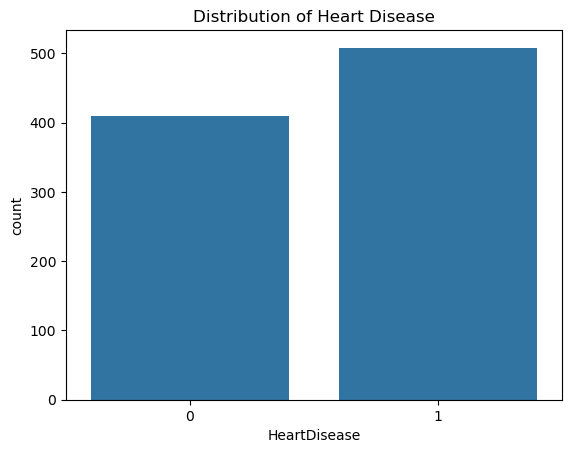

In [55]:
# Plot distribution of HeartDisease
sns.countplot(x='HeartDisease', data=df)
plt.title('Distribution of Heart Disease')
plt.show()


### correlation can only be calculated between numeric values (e.g floats or integers):

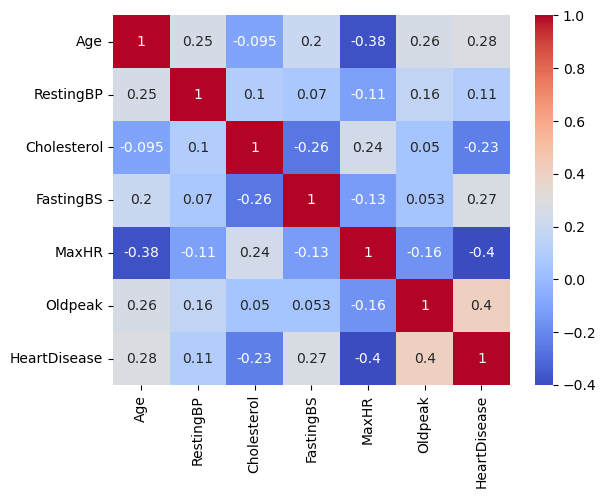

In [56]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

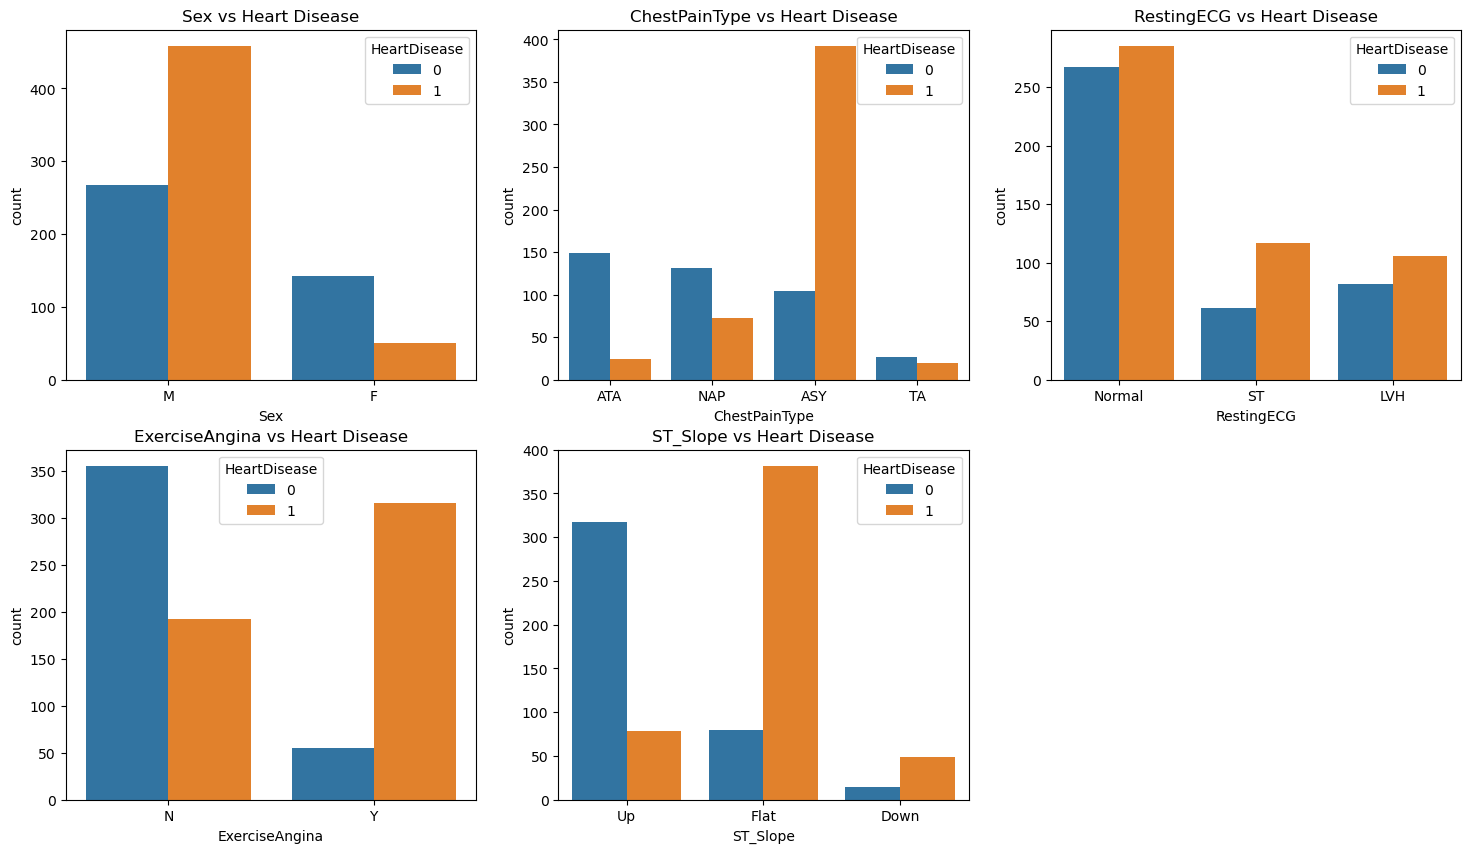

In [57]:
# Plot categorical features

categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

plt.figure(figsize=(18, 10)) 

for i, col in enumerate(categorical_cols):
    plt.subplot(2, 3, i + 1)
    sns.countplot(x=col, hue='HeartDisease', data=df)
    plt.title(f'{col} vs Heart Disease')
    plt.xticks

plt.show()



In [58]:
# Label Encoding for binary categorical features
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['ExerciseAngina'] = le.fit_transform(df['ExerciseAngina'])

# One-Hot Encoding for multi-class categorical features
df = pd.get_dummies(df, columns=['ChestPainType', 'RestingECG', 'ST_Slope'], drop_first=True)


#### Label Encoding for Binary Features:
* Binary categorical features have only two categories. Label encoding transforms these two categories into numeric values (typically 0 and 1).
* Why it works: There is no inherent order between the two categories, so encoding them as 0 and 1 works well without implying any ranking or relationship.
#### One-Hot Encoding (or pd.get_dummies()) for Multi-Class Features:
* Multi-class categorical features have more than two categories. One-hot encoding creates separate binary columns for each category.
* Why it works: One-hot encoding avoids creating any false order or ranking between categories. It treats each category as independent by assigning a "1" to the relevant category and "0" to the others.

In [59]:
# Define features and target variable
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [60]:
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [61]:
# Initialize and train the model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)

# Predictions
y_pred = rf.predict(X_test_scaled)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.8586956521739131
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.84      0.83        77
           1       0.89      0.87      0.88       107

    accuracy                           0.86       184
   macro avg       0.85      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184

Confusion Matrix:
 [[65 12]
 [14 93]]


### The initial train/test split is great for setting a baseline and holding back some data for a final "real-world" test. However, for comparing multiple models fairly, cross-validation (like cv=5) is better — it ensures every data point is used for both training and validation, just not at the same time. Once you move on to model comparison using cross-validation, you typically go back to the full dataset (X, y) instead of relying on your initial train/test split.

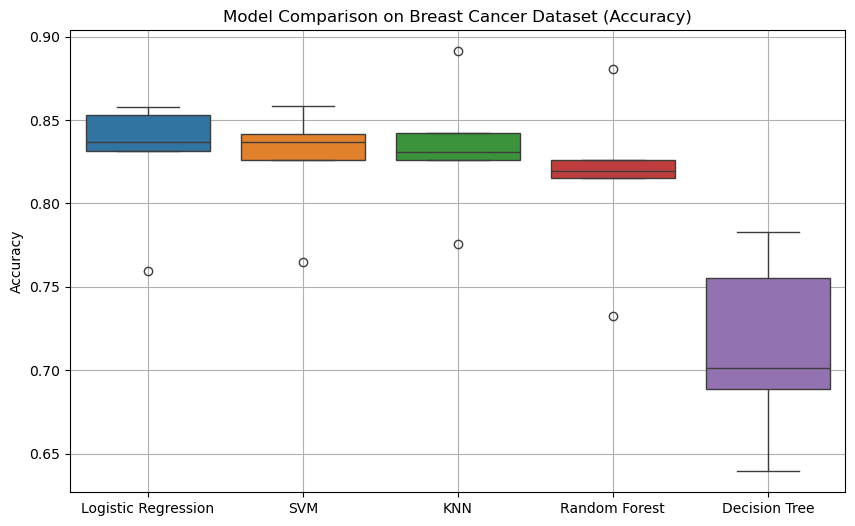

In [65]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Standardize the full dataset for cross-validation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=10000),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier()
}

# Evaluate with cross-validation
results = []
model_names = []

for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy')
    results.append(scores)
    model_names.append(name)

# Plot boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=results)
plt.xticks(ticks=range(len(model_names)), labels=model_names)
plt.title("Model Comparison on Breast Cancer Dataset (Accuracy)")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()


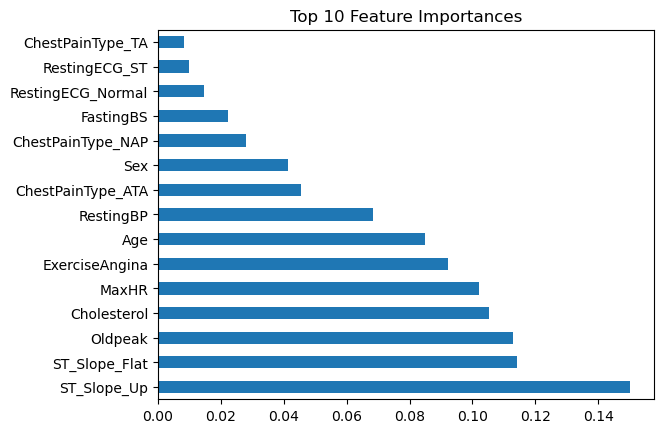

In [46]:
# Feature importance
feature_importances = pd.Series(rf.feature_importances_, index=X.columns)
feature_importances.nlargest(15).plot(kind='barh')
plt.title('Top 15 Feature Importances')
plt.show()


In [67]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

# Initialize the model
model = RandomForestClassifier()

# Use RFE to select top n features
selector = RFE(model, n_features_to_select=10)
selector = selector.fit(X, y)

# Get selected features
selected_features = X.columns[selector.support_]
X_selected_rfe = X[selected_features]

# Check which features were selected
print(selected_features)


Index(['Age', 'Sex', 'RestingBP', 'Cholesterol', 'MaxHR', 'ExerciseAngina',
       'Oldpeak', 'ChestPainType_ATA', 'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')


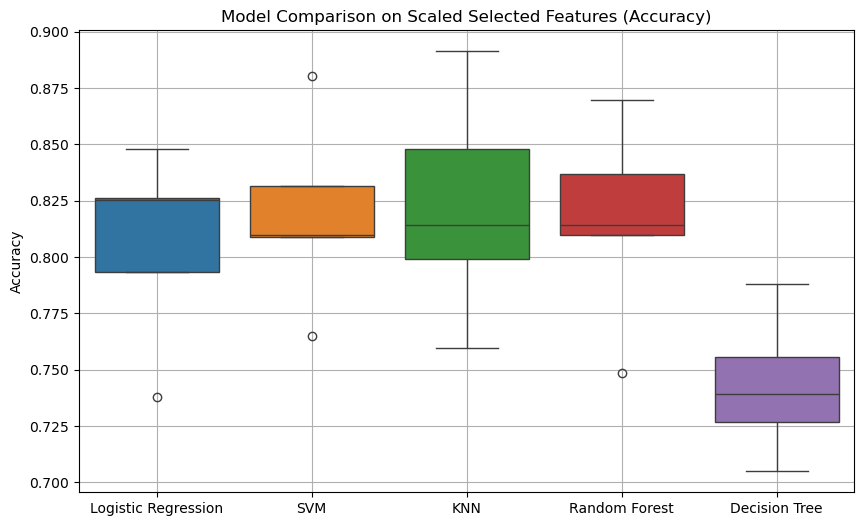

In [74]:
# Standardize the selected features (X_selected_rfe)
scaler = StandardScaler()
X_selected_rfe_scaled = scaler.fit_transform(X_selected_rfe)

# Now evaluate with cross-validation on the scaled, selected features (X_selected_rfe_scaled)
results = []  # To store the accuracy results
model_names = []  # To store the names of the models

for name, model in models.items():
    # Cross-validation with the scaled, selected features (X_selected_rfe_scaled)
    scores = cross_val_score(model, X_selected_rfe_scaled, y, cv=5, scoring='accuracy')
    results.append(scores)
    model_names.append(name)

# Plot boxplot to compare performance across models
plt.figure(figsize=(10, 6))
sns.boxplot(data=results)
plt.xticks(ticks=range(len(model_names)), labels=model_names)
plt.title("Model Comparison on Scaled Selected Features (Accuracy)")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()


#### Feature selection has made a difference, but the complexity of the problem and the nature of the models might prevent dramatic improvements. KNN from removing irrelevant or noisy features, as this leads to more focused and meaningful data for these models, which rely on distance and decision boundaries. Logistic Regression might not perform as well after feature selection because it is a linear model. If some of the selected features had important non-linear relationships or interactions with other features that were removed, the model's performance might drop.

#### The accuracy order change makes sense given the sensitivity of different models to feature selection, scaling, and the specific features selected.

#### The 85% accuracy could be the upper limit for this dataset with the current set of features and models. However, hyperparameter tuning, ensemble learning, and alternative feature selection methods could help you push it further.

* Now that we've completed the major steps of EDA, Preprocessing, Baseline Modeling, Model Comparison, and Feature Selection, it's time to dive into Hyperparameter Tuning.

* When it comes to hyperparameter tuning, we need to apply it to the preprocessed dataset that we're actually using for modeling. This means we should use the scaled data and selected features (since that's what we're training on)